# MVP do modelo de predição de disposição de doenças caridacas

### Sobre o Dataset Heart Disease

Fonte: conjunto consolidado dos quatro datasets da UCI (Cleveland, Hungarian, Switzerland e VA Long Beach), disponibilizado no [Kaggle](
https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data) já com alguns tratamentos de texto. O dataset original por ser encontrado em: https://archive.ics.uci.edu/dataset/45/heart+disease):

- Observações: 920
- Colunas: 16 (inclui metadados como id e dataset)
- Alvo original: num (0–4), onde 0 = ausência de doença e 1–4 = presença em diferentes graus
- Valores ausentes: presentes em múltiplos campos (ex.: trestbps, chol, thalch, exang, oldpeak, slope, ca, thal)

### Esquema das Variáveis (conforme Kaggle)

- id: identificador do paciente
- dataset: origem do caso (Cleveland, Hungarian, Switzerland, VA Long Beach)
- age: idade (anos)
- sex: sexo (Male/Female)
- cp: tipo de dor no peito (typical angina, atypical angina, non-anginal, asymptomatic)
- trestbps: pressão arterial em repouso (mmHg)
- chol: colesterol sérico (mg/dl)
- fbs: glicemia em jejum > 120 mg/dl (True/False)
- restecg: ECG em repouso (normal, st-t abnormality, lv hypertrophy)
- thalch: frequência cardíaca máxima alcançada
- exang: angina induzida por exercício (True/False)
- oldpeak: depressão do ST induzida por exercício (unidades “ST depression”)
- slope: inclinação do segmento ST de pico (upsloping, flat, downsloping)
- ca: número de vasos principais coloridos por fluoroscopia (0–3)
- thal: estado talassêmico (normal, fixed defect, reversable defect)
- num: diagnóstico (0 = sem doença; 1–4 = presença)

## 1. Importações

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Statistics
from scipy import stats

#Tracking
import mlflow 

#Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, f1_score, precision_score, recall_score

## 2. Carregamento dos Dados

In [2]:
path = ('../data/raw_heart_disease_uci.csv')
df = pd.read_csv(path)

# Visualização dos dados de maneira geral
print("Shape do DataFrame:", df.shape)
print("Primeiras 10 linhas do DataFrame:\n", df.head(3))

Shape do DataFrame: (920, 16)
Primeiras 10 linhas do DataFrame:
    id  age   sex    dataset              cp  trestbps   chol    fbs  \
0   1   63  Male  Cleveland  typical angina     145.0  233.0   True   
1   2   67  Male  Cleveland    asymptomatic     160.0  286.0  False   
2   3   67  Male  Cleveland    asymptomatic     120.0  229.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  


### Informação geral do Dataset

In [3]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

=== ESTATÍSTICAS DESCRITIVAS ===



,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 3. Analise Exploratoria de Dados (EDA)
### 3.1 Analise de Missing Values


=== VERIFICAÇÃO DE MISSING VALUES ===

            Coluna  Missing_Count  Missing_Percentage
ca              ca            611               66.41
thal          thal            486               52.83
slope        slope            309               33.59
fbs            fbs             90                9.78
oldpeak    oldpeak             62                6.74
trestbps  trestbps             59                6.41
exang        exang             55                5.98
thalch      thalch             55                5.98
chol          chol             30                3.26
restecg    restecg              2                0.22


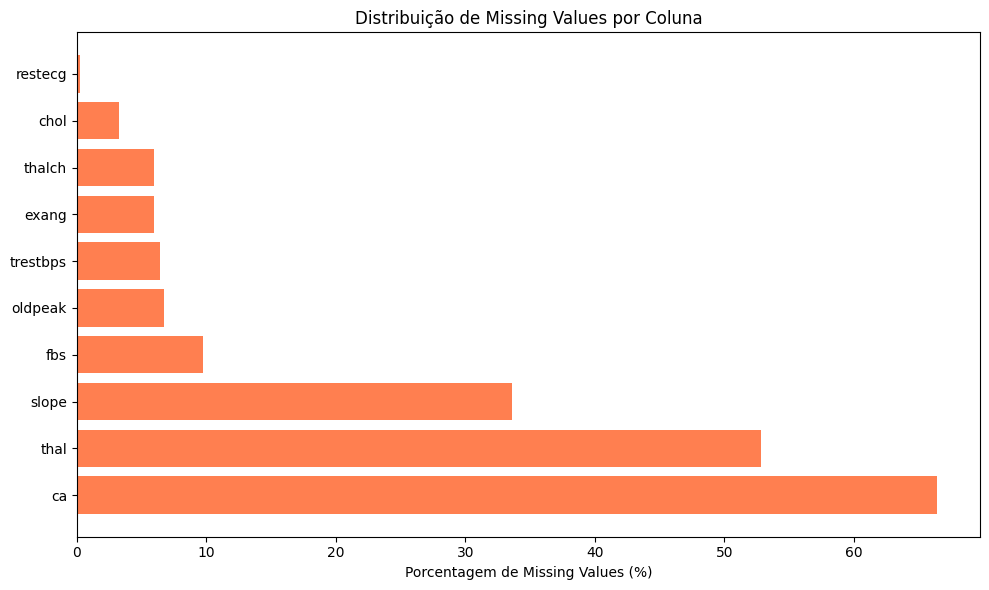

In [4]:
print("\n=== VERIFICAÇÃO DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
  'Coluna': df.columns,
  'Missing_Count': df.isnull().sum(),
  'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
  by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
  print(missing_values)
  # Visualizar missing values
  plt.figure(figsize=(10, 6))
  plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
  plt.xlabel('Porcentagem de Missing Values (%)')
  plt.title('Distribuição de Missing Values por Coluna')
  plt.tight_layout()
  plt.show()
  
else:
    print("Nenhum missing value detectado!")

### 3.2 Análise da Variável Target


=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem de cada classe:
 target
1    509
0    411
Name: count, dtype: int64

Porcentagem de cada classe:
Com doença (1): 55.33%
Sem doença (0): 44.67%


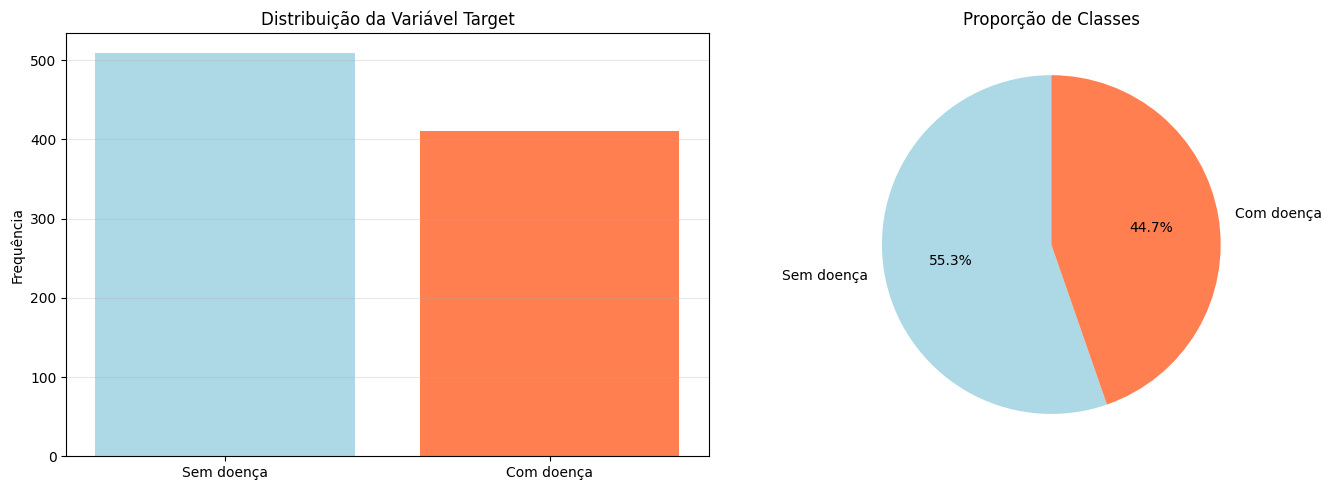

O dataset está balanceado.


In [5]:
#Renomear a coluna 'num' para 'target' e binarizar os valores em 0 ou 1
df.rename(columns={'num': 'target'}, inplace=True)
df['target'] = (df['target'] > 0).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem de cada classe:\n", target_counts)
print("\nPorcentagem de cada classe:")

# Exibir porcentagem de cada classe com rótulos em porcentagem usando f-strings
for idx, pct in target_percentages.items():
    label = "Sem doença" if idx == 0 else "Com doença"
    print(f"{label} ({idx}): {pct:.2f}%")
    
# Visualização da distribuição da variável target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Sem doença', 'Com doença'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Sem doença', 'Com doença'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

ratio = target_counts.min()/target_counts.max()
if ratio < 0.5:
    print("O dataset está desbalanceado. Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("O dataset está balanceado.")

📊 Iniciando análise comparativa contra o alvo: 'target'
🚫 Colunas ignoradas: ['id', 'dataset']



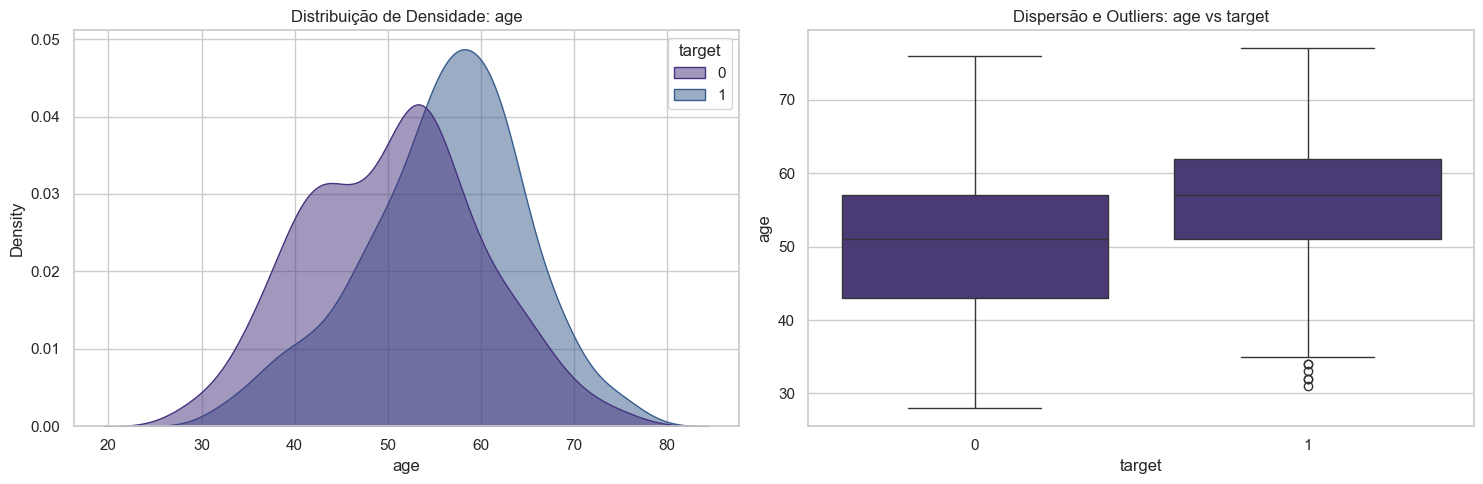

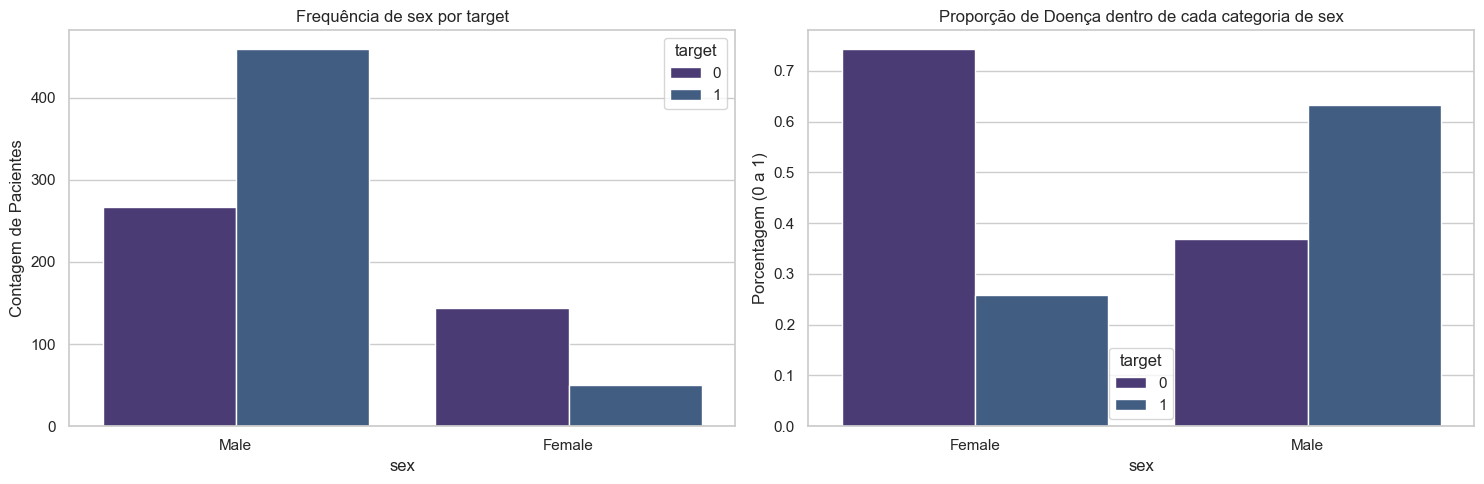

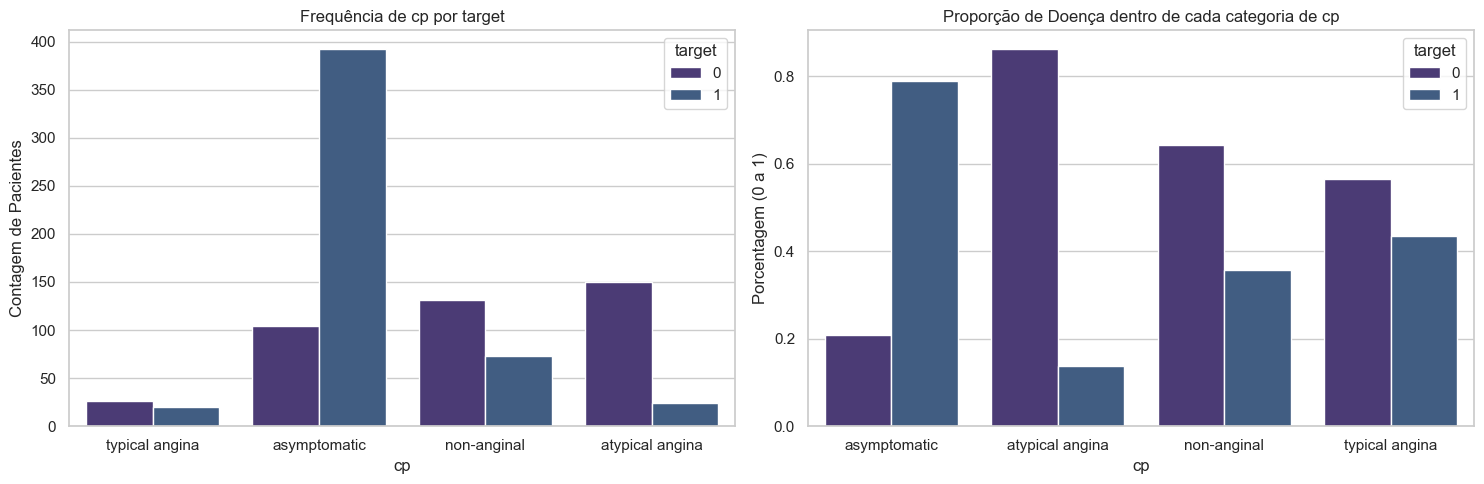

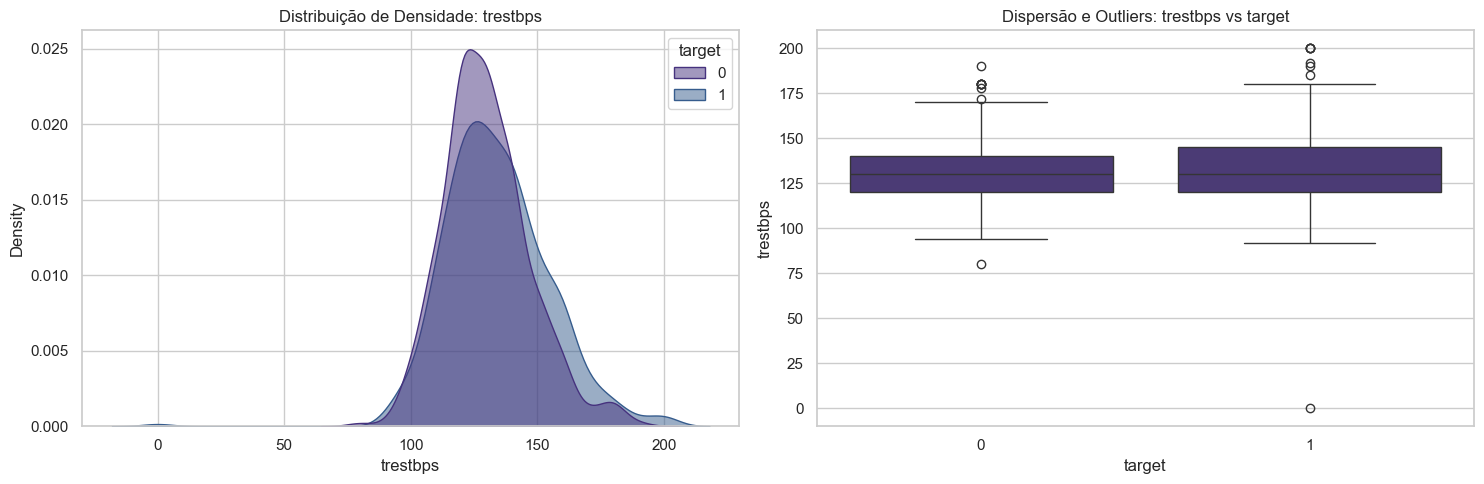

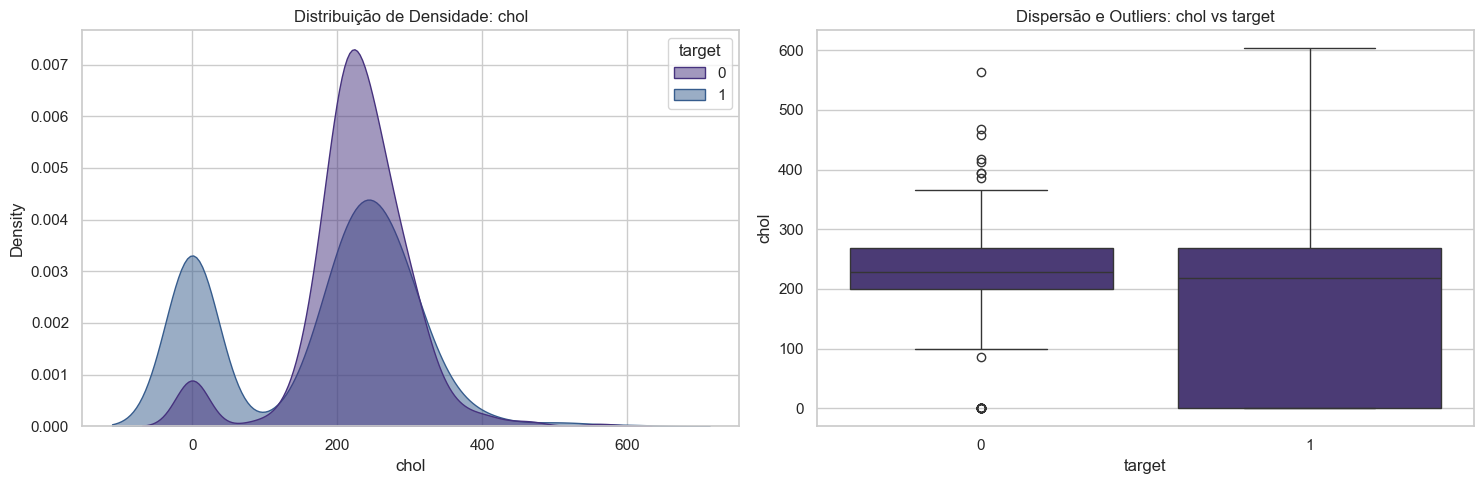

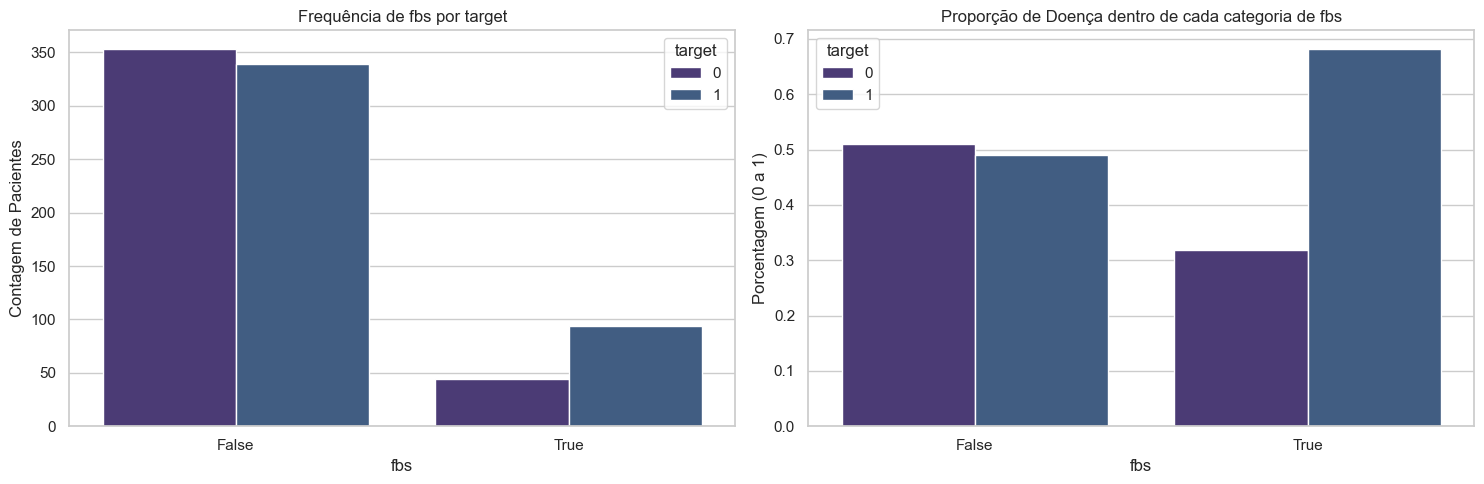

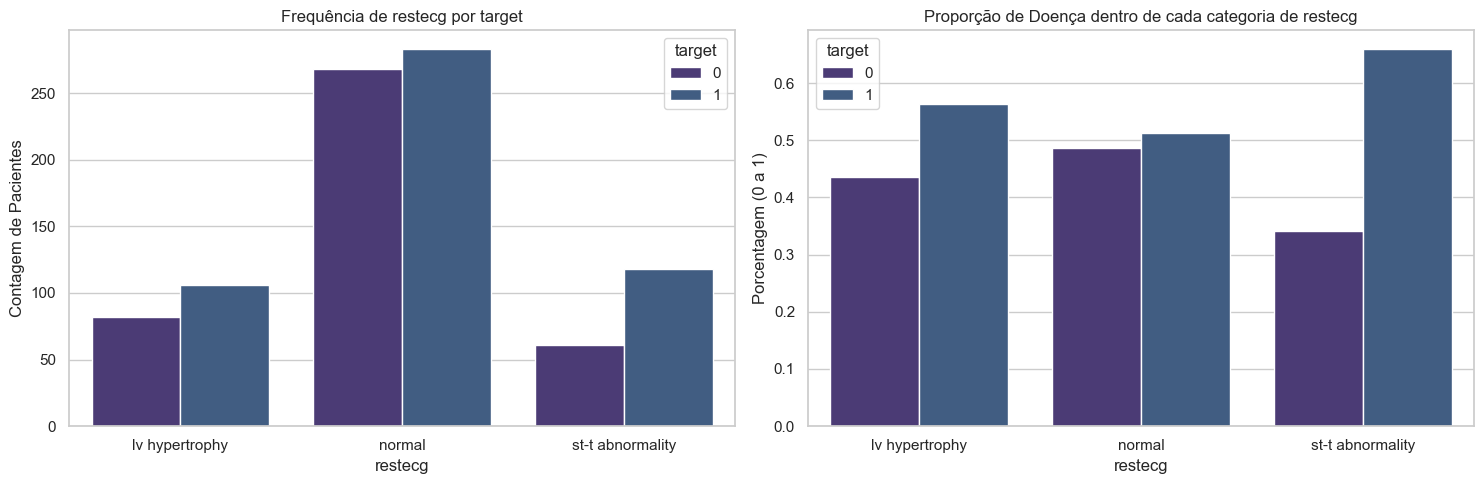

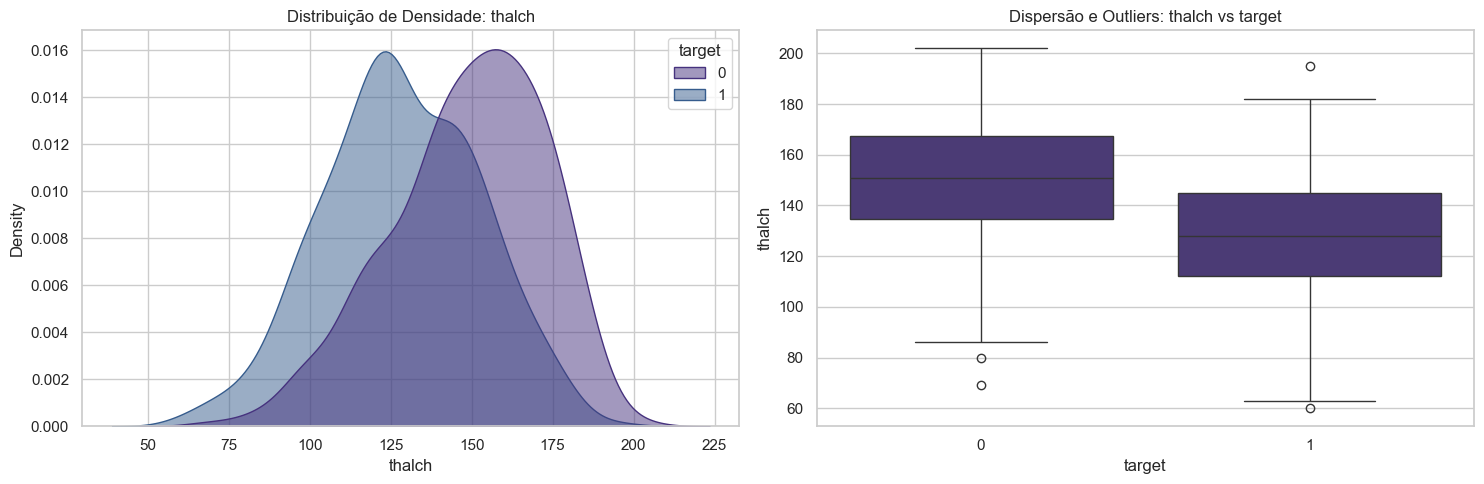

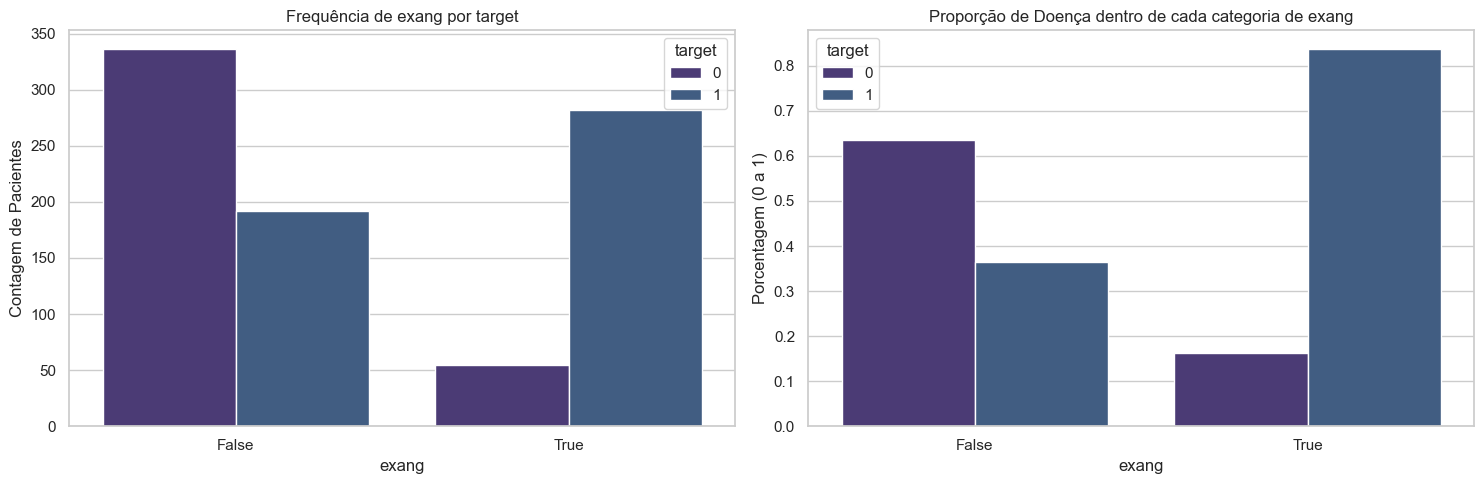

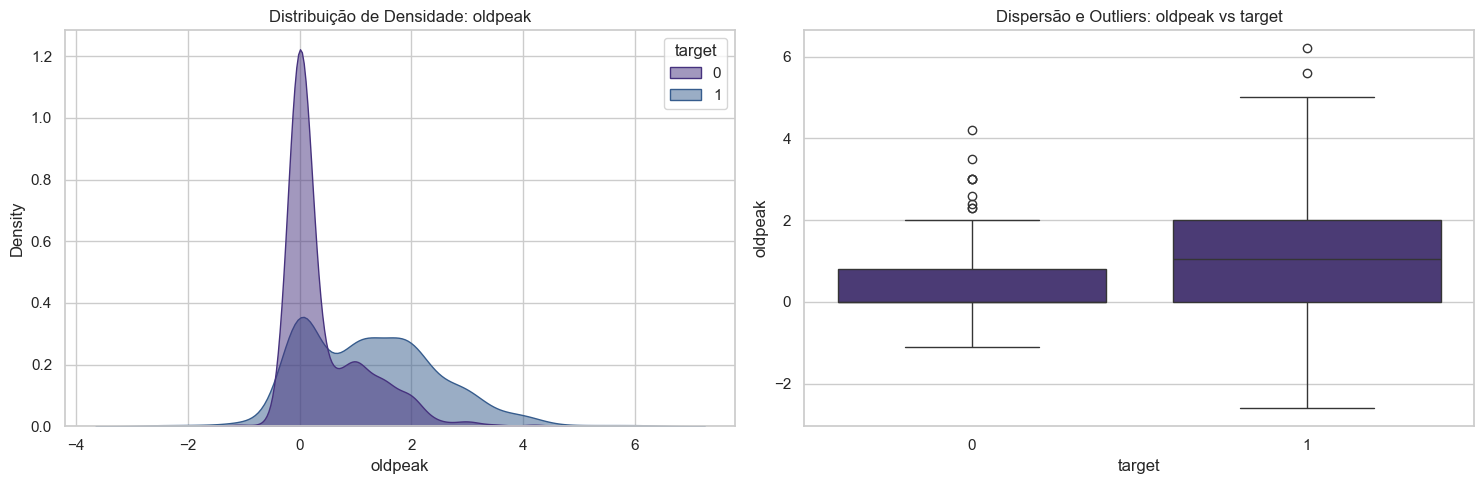

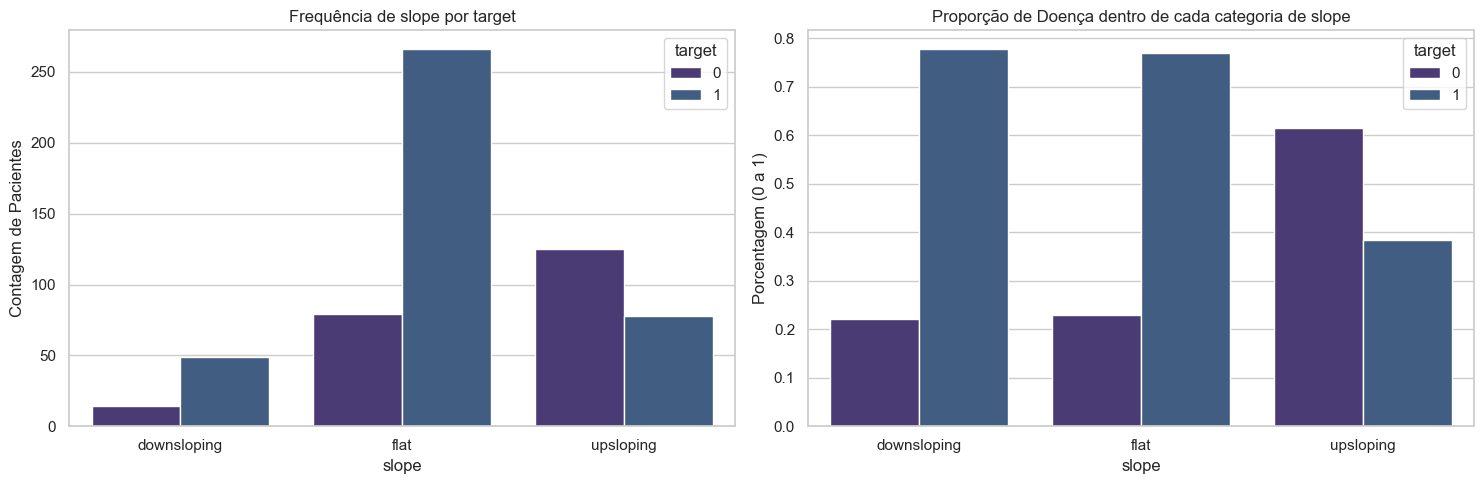

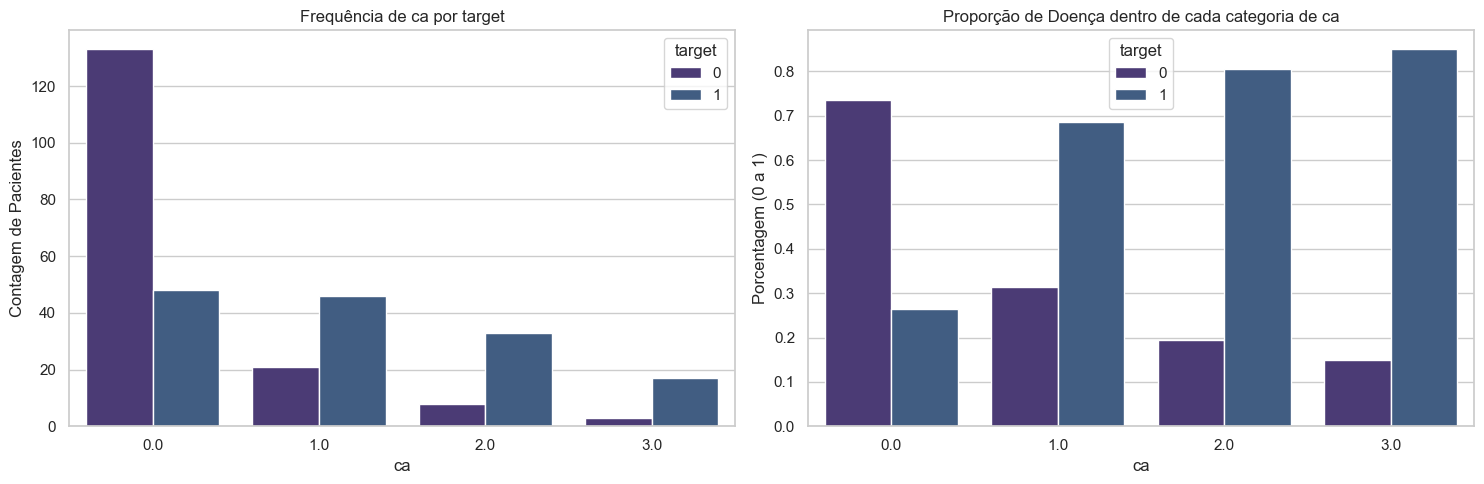

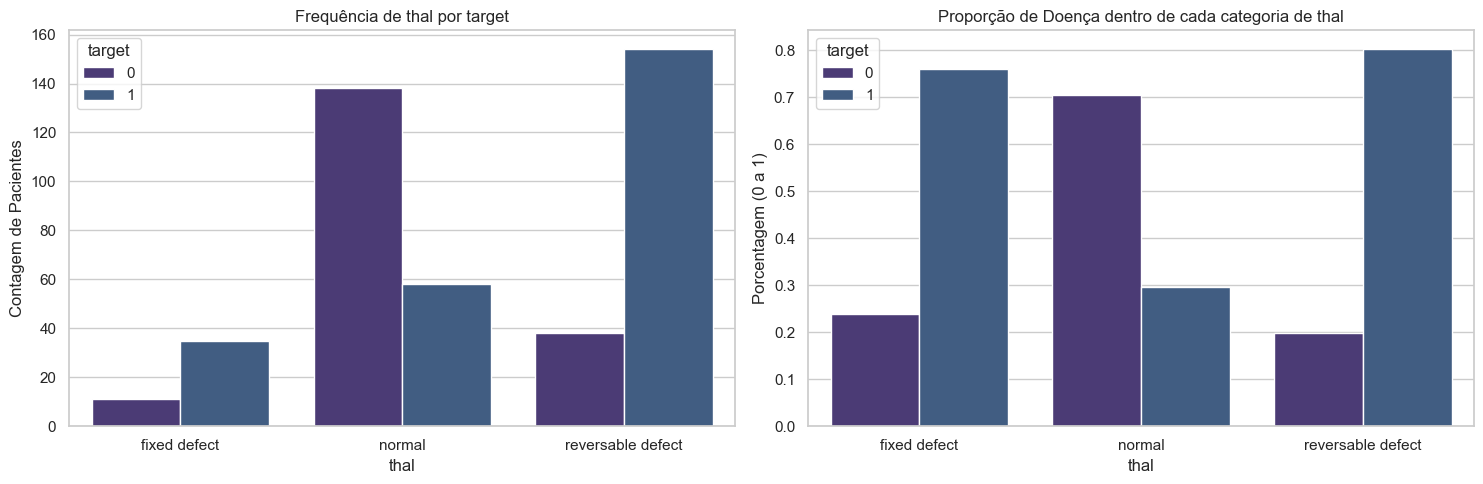

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def perform_full_target_analysis(df, target_col='target', exclude_cols=None):
    """
    Realiza uma análise exploratória automatizada comparando todas as variáveis com o target.
    
    Args:
        df (pd.DataFrame): O DataFrame de dados.
        target_col (str): O nome da coluna alvo (presença/ausência de doença).
        exclude_cols (list): Lista de colunas a serem ignoradas (ex: 'id', 'dataset').
    """
    # 1. Configurações Globais de Estilo
    sns.set_theme(style="whitegrid", palette="viridis")
    if exclude_cols is None:
        exclude_cols = ['id', 'dataset']
    
    # 2. Filtragem de Colunas
    # Remove o target e as colunas de exclusão da lista de iteração
    cols_to_plot = [col for col in df.columns if col not in exclude_cols and col != target_col]
    
    print(f"📊 Iniciando análise comparativa contra o alvo: '{target_col}'")
    print(f"🚫 Colunas ignoradas: {exclude_cols}\n")

    for col in cols_to_plot:
        # Criamos uma figura com dois subplots (lado a lado)
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Identificação de Variável Categórica vs Numérica
        # Critério: Menos de 10 valores únicos OU tipo object/category
        is_categorical = df[col].nunique() <= 10 or df[col].dtype == 'object'
        
        if is_categorical:
            # --- VISUALIZAÇÃO CATEGÓRICA ---
            # Subplot 1: Frequência Absoluta
            sns.countplot(data=df, x=col, hue=target_col, ax=axes[0])
            axes[0].set_title(f'Frequência de {col} por {target_col}')
            axes[0].set_ylabel('Contagem de Pacientes')
            
            # Subplot 2: Proporção Relativa (Normalizada)
            # Ajuda a ver a taxa de incidência independente do tamanho da amostra
            prop_df = (df.groupby(col)[target_col]
                       .value_counts(normalize=True)
                       .rename('porcentagem')
                       .reset_index())
            sns.barplot(data=prop_df, x=col, y='porcentagem', hue=target_col, ax=axes[1])
            axes[1].set_title(f'Proporção de Doença dentro de cada categoria de {col}')
            axes[1].set_ylabel('Porcentagem (0 a 1)')
            
        else:
            # --- VISUALIZAÇÃO NUMÉRICA ---
            # Subplot 1: Distribuição de Densidade (KDE)
            sns.kdeplot(data=df, x=col, hue=target_col, fill=True, common_norm=False, ax=axes[0], alpha=0.5)
            axes[0].set_title(f'Distribuição de Densidade: {col}')
            
            # Subplot 2: Boxplot para identificar Outliers e Quartis
            sns.boxplot(data=df, x=target_col, y=col, ax=axes[1])
            axes[1].set_title(f'Dispersão e Outliers: {col} vs {target_col}')

        plt.tight_layout()
        plt.show()
        
perform_full_target_analysis(df)


### 3.3 Análise de Outliers



=== ANÁLISE DE OUTLIERS ===



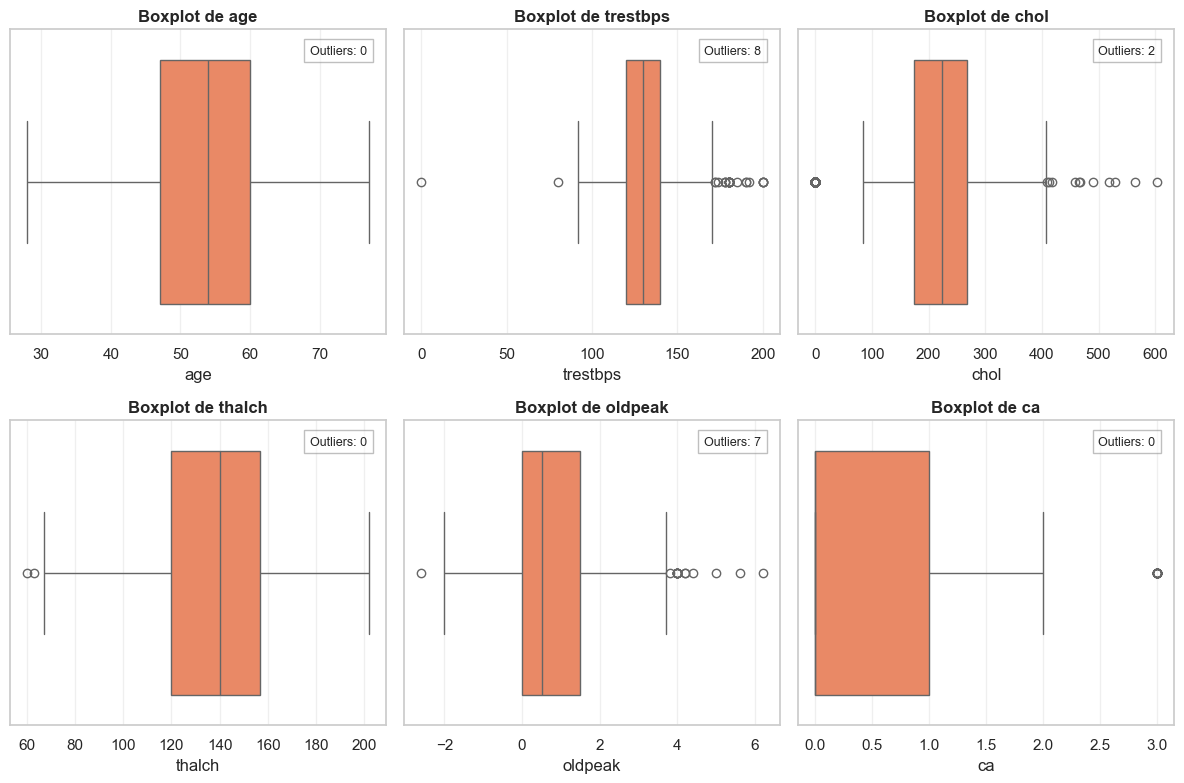

In [7]:
# Refatoração do dataset para selecionar colunas numéricas e sem id e target 
numeric_cols = df.select_dtypes(include=[np.number]).columns 
numeric_cols = numeric_cols.drop(['id','target'])

print("=== ANÁLISE DE OUTLIERS ===\n")

# Configuração da grade de subplots
n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, nrows*4))
axes = axes.ravel()

# Achatar a matriz de eixos para facilitar a iteração
for idx, col in enumerate(numeric_cols):
  sns.boxplot(x=df[col], ax=axes[idx], color='coral')
  axes[idx].set_title(f'Boxplot de {col}', fontweight='bold')
  axes[idx].set_xlabel(col)
  axes[idx].grid(axis='x', alpha=0.3)
  col_zscore = np.abs(stats.zscore(df[col].dropna()))
  outliers_count = (col_zscore > 3).sum()
  axes[idx].text(0.95, 0.95, f'Outliers: {outliers_count}',
                 transform=axes[idx].transAxes, fontsize=9,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
  
for ax in axes[n:]:
  fig.delaxes(ax)
  
plt.tight_layout()
plt.show() 

### 3.4 Análise de Anomalias e Valores Inválidos

In [8]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

anomalies = []

age_anomalies = df[(df['age'] < 0) | (df['age'] > 120)]

# 1. Idade (deve ser entre 0 e 120 anos)
if len(age_anomalies) > 0:
    anomalies.append(f"Idade fora do intervalo válido: {len(age_anomalies)} casos")
  
# 2. Pressão arterial (trestbps) - valores típicos: 80-200 mmHg
bp_anomalies = df[(df['trestbps'] < 80) | (df['trestbps'] > 200)]
if len(bp_anomalies) > 0:
    anomalies.append(f"Pressão arterial fora do intervalo típico: {len(bp_anomalies)} casos")
    print(f"⚠️ Pressão arterial anormal detectada: {len(bp_anomalies)} casos")
    print(f"   Valores: min={df['trestbps'].min()}, max={df['trestbps'].max()}")
    
# 3. Colesterol (chol) - valores típicos: 100-400 mg/dL
chol_anomalies = df[(df['chol'] < 100) | (df['chol'] > 400)]
if len(chol_anomalies) > 0:
    anomalies.append(f"Colesterol fora do intervalo típico: {len(chol_anomalies)} casos")
    print(f"⚠️ Colesterol anormal detectado: {len(chol_anomalies)} casos")
    print(f"   Valores: min={df['chol'].min()}, max={df['chol'].max()}")

# 4. Frequência cardíaca máxima (thalch) - valores típicos: 60-200 bpm
thalach_anomalies = df[(df['thalch'] < 60) | (df['thalch'] > 200)]
if len(thalach_anomalies) > 0:
    anomalies.append(f"Frequência cardíaca máxima fora do intervalo típico: {len(thalach_anomalies)} casos")
    print(f"⚠️ Frequência cardíaca máxima anormal detectada: {len(thalach_anomalies)} casos")
    print(f"   Valores: min={df['thalch'].min()}, max={df['thalch'].max()}")

# Teste de mapeamento para todas as variáveis categóricas
print("\n=== TESTE DE MAPEAMENTO - TODAS AS COLUNAS CATEGÓRICAS ===\n")

# Criar cópia para teste
df_test = df.copy()

# Mapeamentos para todas as colunas categóricas
categorical_mappings = {
    'sex': {'Male': 0, 'Female': 1},
    'cp': {
        'typical angina': 0,
        'atypical angina': 1,
        'non-anginal': 2,
        'asymptomatic': 3
    },
    'fbs': {True: 1, False: 0},
    'restecg': {
        'normal': 0,
        'st-t abnormality': 1,
        'lv hypertrophy': 2
    },
    'exang': {True: 1, False: 0},
    'slope': {
        'upsloping': 0,
        'flat': 1,
        'downsloping': 2
    },
    'ca': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4},
    'thal': {
        'normal': 0,
        'fixed defect': 1,
        'reversable defect': 2
    }
}
categorical_checks = {
    'sex': [0, 1],
    'cp': [0, 1, 2, 3],
    'fbs': [0, 1],
    'restecg': [0, 1, 2],
    'exang': [0, 1],
    'slope': [0, 1, 2],
    'ca': [0, 1, 2, 3, 4],
    'thal': [0, 1, 2, 3]
}

anomalies = []

# Aplicar mapeamento para cada coluna
for col, mapping in categorical_mappings.items():
  if col in df_test.columns:
    # Atribui cada valor categórico ao seu respectivo código numérico
    df_test[col] = df_test[col].map(mapping)
    # Verificar NaN (não mapeados)
    nan_count = df_test[col].isna().sum()
    if nan_count > 0:
        anomalies.append(f"{col}: {nan_count} valores não mapeados (NaN)")
        print(f"⚠️ {col}: {nan_count} valores não mapeados (NaN)")
    
    # Verificar valores fora do domínio
    invalid_values = df_test[~df_test[col].isin(categorical_checks[col]) & df_test[col].notna()]
    if len(invalid_values) > 0:
      anomalies.append(f"{col}: {len(invalid_values)} valores fora do domínio {categorical_checks[col]}")
      print(f"⚠️ {col}: {len(invalid_values)} valores fora do domínio esperado {categorical_checks[col]}")
    else:
      print(f"✓ {col}: Todos os valores mapeados corretamente dentro do domínio esperado de \
            \n{mapping} para {categorical_checks[col]}")

if len(anomalies) == 0:
    print("✓ Todas as colunas mapeadas corretamente!")
else:
    print(f"\n📊 Total de anomalias: {len(anomalies)}")

# # Amostra dos dados mapeados
# print("\n=== AMOSTRA DOS DADOS APÓS MAPEAMENTO ===")
# print(df_test[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']].head(10))
   
duplicates = df.duplicated().sum()
print(f"\n=== DUPLICADOS ===")
print(f"Registros duplicados: {duplicates}")
if duplicates > 0:
    print("⚠️ Considere remover ou investigar registros duplicados")



=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

⚠️ Pressão arterial anormal detectada: 1 casos
   Valores: min=0.0, max=200.0
⚠️ Colesterol anormal detectado: 186 casos
   Valores: min=0.0, max=603.0
⚠️ Frequência cardíaca máxima anormal detectada: 1 casos
   Valores: min=60.0, max=202.0

=== TESTE DE MAPEAMENTO - TODAS AS COLUNAS CATEGÓRICAS ===

✓ sex: Todos os valores mapeados corretamente dentro do domínio esperado de             
{'Male': 0, 'Female': 1} para [0, 1]
✓ cp: Todos os valores mapeados corretamente dentro do domínio esperado de             
{'typical angina': 0, 'atypical angina': 1, 'non-anginal': 2, 'asymptomatic': 3} para [0, 1, 2, 3]
⚠️ fbs: 90 valores não mapeados (NaN)
✓ fbs: Todos os valores mapeados corretamente dentro do domínio esperado de             
{True: 1, False: 0} para [0, 1]
⚠️ restecg: 2 valores não mapeados (NaN)
✓ restecg: Todos os valores mapeados corretamente dentro do domínio esperado de             
{'normal': 0, 'st-t abnormality': 1, 'lv h

### 3.5 Análise de Distribuições


=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

  Coluna  Skewness  Kurtosis          Interpretação
     age    -0.196    -0.383                 Normal
trestbps     0.213     2.959                 Normal
    chol    -0.614     0.062 Assimétrica à esquerda
  thalch    -0.211    -0.480                 Normal
 oldpeak     1.041     1.127  Assimétrica à direita
      ca     1.166     0.199  Assimétrica à direita


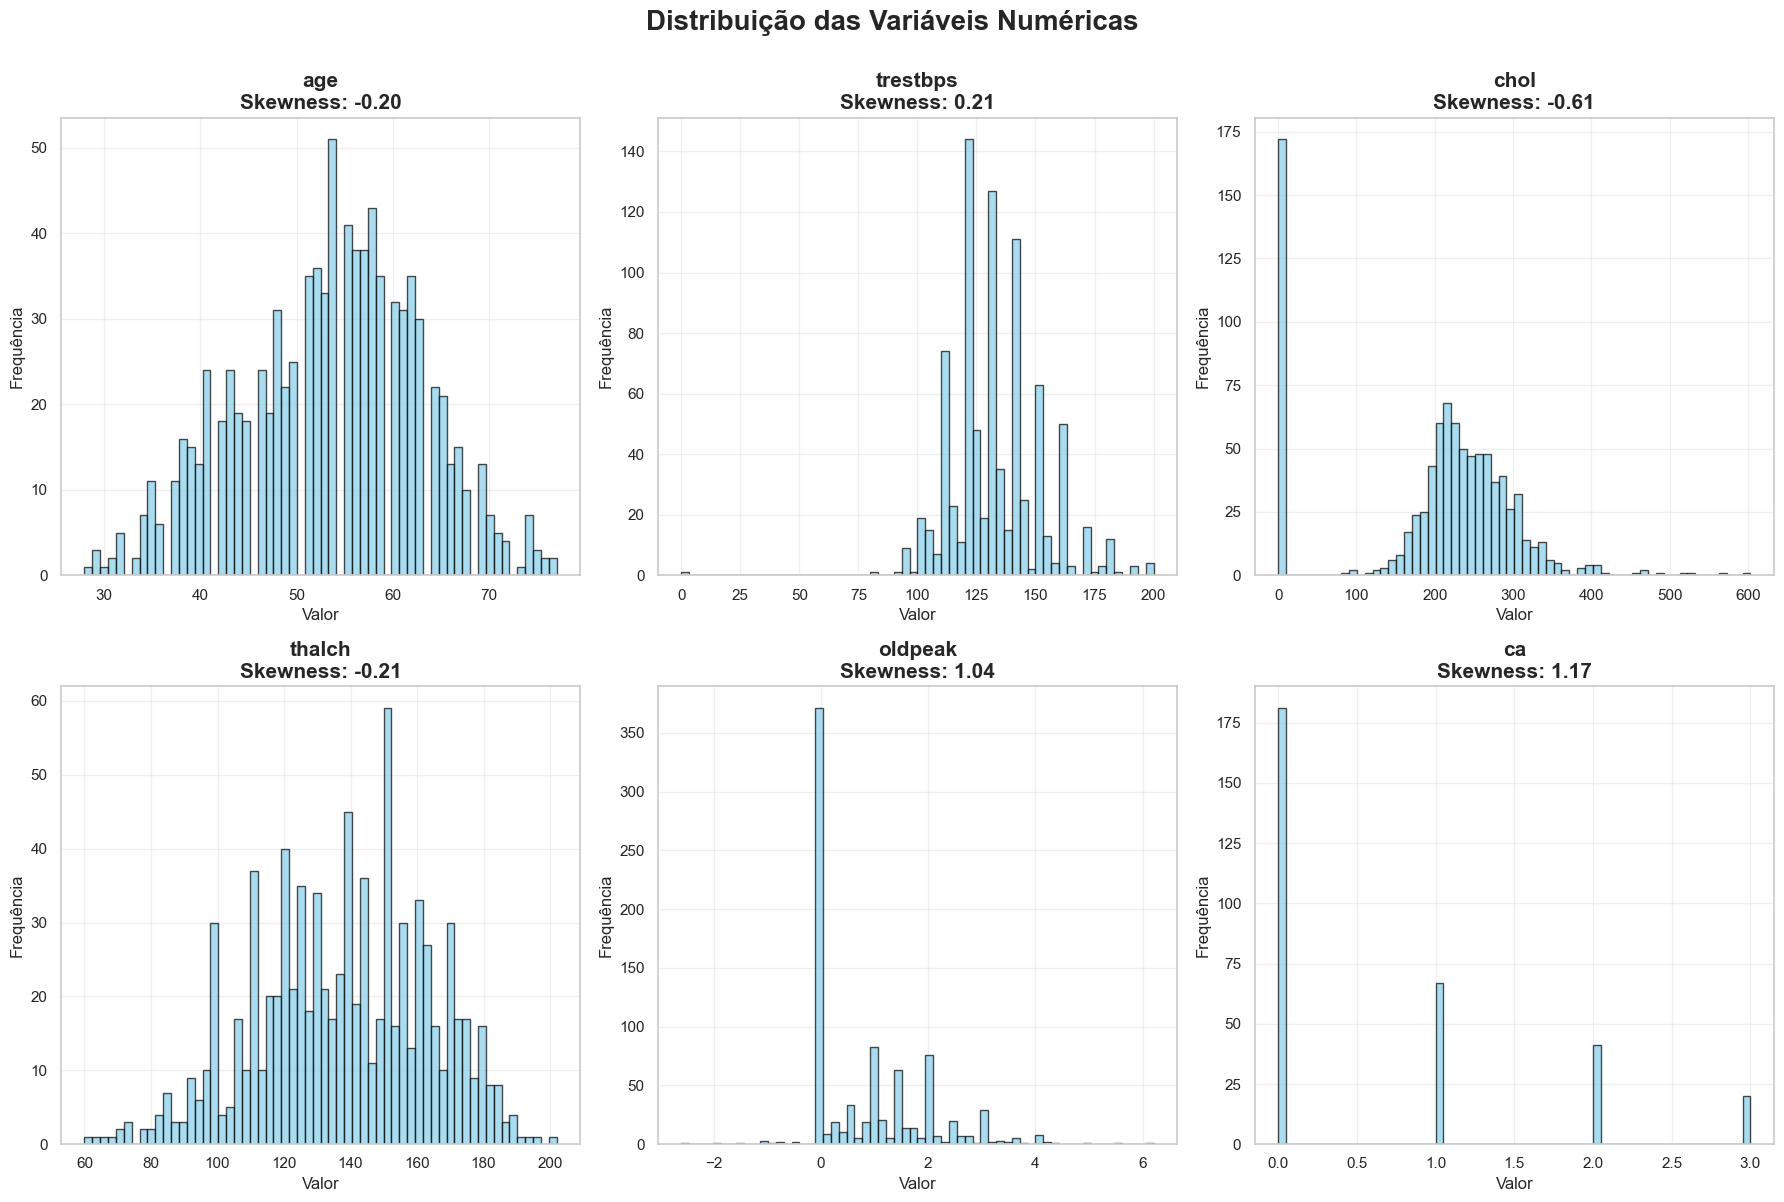

In [9]:
import json
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
  skewness = df[col].skew()
  kurtosis = df[col].kurtosis()
  distribution_stats.append({
    'Coluna': col,
    'Skewness': round(skewness, 3),
    'Kurtosis': round(kurtosis, 3),
    'Interpretação': 'Normal' if abs(skewness) < 0.5 else \
    ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
  })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizando as distribuições com histogramas e KDE
fig, axes = plt.subplots(2, 3, figsize=(18,12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
  if idx < len(axes):
    axes[idx].hist(df[col].dropna(), bins=60, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}\nSkewness: {df[col].skew():.2f}', fontsize=15, fontweight='bold')
    axes[idx].set_xlabel("Valor")
    axes[idx].set_ylabel("Frequência")
    axes[idx].grid(axis='both', alpha=0.3)

# Remover subplots vazios
# Itera sobre os índices dos subplots e remove os que estão além do número de colunas numéricas
for idx in range(len(numeric_cols), len(axes)):
  fig.delaxes(axes[idx])
  
# Exibe os gráficos
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=20, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

### 3.6 Análise de Correlações


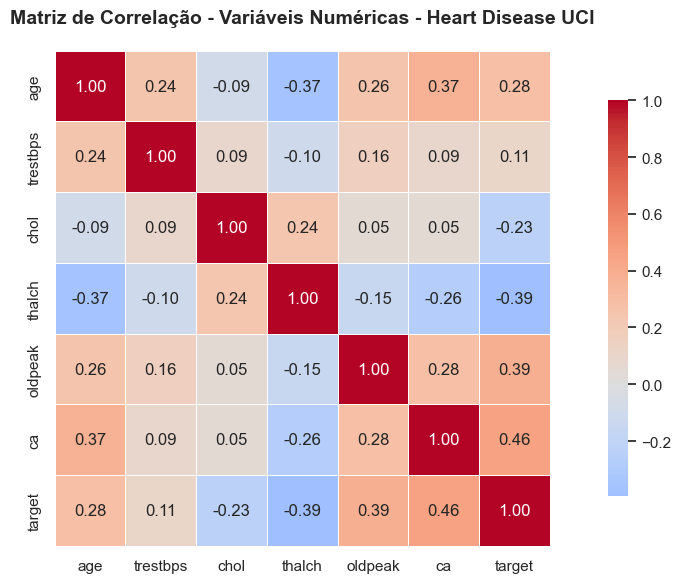

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target      1.000000
ca          0.455599
oldpeak     0.385528
age         0.282700
trestbps    0.106233
chol       -0.230583
thalch     -0.394503

=== MULTICOLINEARIDADE (Correlação entre features) ===
✓ Nenhuma correlação forte (> 0.7) detectada entre features (excluindo target)


In [10]:
# Matriz de correlação para variáveis numéricas
df_numeric = df.select_dtypes(include=[np.number]).drop(columns=['id'])
corr_numeric = df_numeric.corr()

# Visualizar matriz de correlação das variáveis numéricas
plt.figure(figsize=(12,6))
sns.heatmap(corr_numeric, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Variáveis Numéricas - Heart Disease UCI', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target (acima de 0.5 ou abaixo de -0.5)
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr.to_string())

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
  for j in range(i+1, len(corr_numeric.columns)):
    if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
      high_corr_pairs.append({
        'Feature 1': corr_numeric.columns[i],
        'Feature 2': corr_numeric.columns[j],
        'Correlação': round(corr_numeric.iloc[i, j], 3)
      })

if len(high_corr_pairs) > 0:
  high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
  print("Pares de features com correlação > 0.7:\n")
  print(high_corr_df.to_string(index=False))
  print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte (> 0.7) detectada entre features (excluindo target)")

### 3.7 Análise da Distribuição da Variável Target entre as features


## 4. Prearação dos Dados
### 4.1 Tratamento de Missing Values


In [11]:
print("=== TRATAMENTO DE MISSING VALUES ===\n")

# Copiar o dataframe original para preservar os dados brutos
df_clean = df.copy()

# Imputação para variáveis numéricas usando a mediana
# Seleciona apenas as colunas numéricas que possuem valores faltantes
num_missing = df_clean.select_dtypes(include=[np.number]) \
  .columns[df_clean.select_dtypes(include=[np.number]).isna().any()].tolist()

for col in num_missing:
  if col in df_clean.columns:
    median = df_clean[col].median()
    df_clean[col].fillna(median, inplace=True)
    print(f"{col}: Imputado com mediana ({median:.2f})")
  
# Imputação para variáveis categóricas usando a moda
# Seleciona apenas as colunas categóricas que possuem valores faltantes
cat_missing = df_clean.select_dtypes(include=[np.object_]) \
  .columns[df_clean.select_dtypes(include=[np.object_]).isna().any()].tolist()

for col in cat_missing:
  if col in df_clean.columns:
    mode = df_clean[col].mode()[0]
    df_clean[col].fillna(mode, inplace=True)
    print(f"{col}: Imputado com moda ({mode})")
  
print("\n✓ Tratamento de missing values concluído!")
print(f"Shape após imputação: {df_clean.shape}")
print("Valores ausentes restantes por coluna:")
print(df_clean.isnull().sum())
    

=== TRATAMENTO DE MISSING VALUES ===

trestbps: Imputado com mediana (130.00)
chol: Imputado com mediana (223.00)
thalch: Imputado com mediana (140.00)
oldpeak: Imputado com mediana (0.50)
ca: Imputado com mediana (0.00)
fbs: Imputado com moda (False)
restecg: Imputado com moda (normal)
exang: Imputado com moda (False)
slope: Imputado com moda (flat)
thal: Imputado com moda (normal)

✓ Tratamento de missing values concluído!
Shape após imputação: (920, 16)
Valores ausentes restantes por coluna:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### 4.2 Codificação de Variáveis Categóricas (One-hot Encoding)


In [12]:
# Remoção da coluna 'dataset' se existir, pois é redundante para a análise
df_clean.drop(columns=['dataset','id'], inplace=True, errors='ignore')

# One-hot enconding das variáveis categóricas relevantes
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"Shape após one-hot encoding: {df_encoded.shape}")
df_encoded.head()

Shape após one-hot encoding: (920, 19)


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,1,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


## 5. Experimentação e MVP


In [13]:
import mlflow
from mlflow.tracking import MlflowClient
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Divida o dataset em features (X) e target (y)
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# Divida em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Configuração do MLflow para rastreamento local
MLFLOW_TRACKING_URI = "file:///C:/mlflow"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

mlflow.set_experiment("heart_disease_classification_mvp")
#run_name="logistic_regression_baseline_v3"
with mlflow.start_run():
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)

    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_f1_score", test_f1)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)

    overfitting = train_accuracy - test_accuracy
    mlflow.log_metric("overfitting", overfitting)

    mlflow.sklearn.log_model(model, "model")

    print(f"=== LOGISTIC REGRESSION ===")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy:  {test_accuracy:.4f}")
    print(f"Test F1 Score:  {test_f1:.4f}")

    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall:    {test_recall:.4f}")
    print(f"Overfitting:    {overfitting:.4f}")

2026/03/27 02:01:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 02:01:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/27 02:01:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


=== LOGISTIC REGRESSION ===
Train Accuracy: 0.8207
Test Accuracy:  0.8043
Test F1 Score:  0.8302
Test Precision: 0.8544
Test Recall:    0.8073
Overfitting:    0.0163


### 6. Persistir o Dataframe pré-processado


In [14]:
# Persistir o dataframe pré-processado
df_encoded.to_csv("../data/heart_disease_uci_preprocessed.csv", index=False)

### 7. Persistir modelo

In [15]:
# Persistir o modelo treinado com MLFlow
mlflow.sklearn.log_model(model, "logistic_regression_model")

# Persistir o modelo usando joblib
import joblib
joblib.dump(model, "../models/baseline_model.joblib")

2026/03/27 02:04:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 02:04:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/27 02:04:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


['../models/baseline_model.joblib']